In [1]:
# ============================================================================
# CELL 1: NAFNET – ARCHITECTURE, DATASET, EVAL & HELPERS
# ============================================================================

import os
import sys
import subprocess
import gc
import torch
import torch.nn as nn
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import ConnectionPatch, Rectangle
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

# Install lpips if needed
try:
    import lpips
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "lpips"])
    import lpips

print("="*80)
print("🚀 CELL 1: NAFNet Architecture & Helpers")
print("="*80)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

# -------------------------------
# NAFNet Architecture (width=64)
# -------------------------------
class SimpleGate(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        return x1 * x2

class NAFBlock(nn.Module):
    def __init__(self, c, DW_Expand=2, FFN_Expand=2):
        super().__init__()
        dw_channel = c * DW_Expand
        self.conv1 = nn.Conv2d(c, dw_channel, 1, 1, 0, bias=True)
        self.conv2 = nn.Conv2d(dw_channel, dw_channel, 3, 1, 1, groups=dw_channel, bias=True)
        self.conv3 = nn.Conv2d(dw_channel // 2, c, 1, 1, 0, bias=True)
        self.sca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(dw_channel // 2, dw_channel // 2, 1, 1, 0, bias=True),
        )
        self.sg = SimpleGate()
        self.norm1 = nn.LayerNorm(c, eps=1e-6)
        self.norm2 = nn.LayerNorm(c, eps=1e-6)
        ffn_channel = FFN_Expand * c
        self.conv4 = nn.Conv2d(c, ffn_channel, 1, 1, 0, bias=True)
        self.conv5 = nn.Conv2d(ffn_channel // 2, c, 1, 1, 0, bias=True)
        self.beta = nn.Parameter(torch.zeros((1, c, 1, 1)), requires_grad=True)
        self.gamma = nn.Parameter(torch.zeros((1, c, 1, 1)), requires_grad=True)

    def forward(self, inp):
        x = self.norm1(inp.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)
        x = self.conv3(self.sg(self.conv2(self.conv1(x))) * self.sca(self.sg(self.conv2(self.conv1(x)))))
        y = inp + x * self.beta
        x = self.norm2(y.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)
        x = self.conv5(self.sg(self.conv4(x)))
        return y + x * self.gamma

class NAFNet(nn.Module):
    def __init__(self, img_channel=3, width=64, enc_blk_nums=[1, 1, 1, 28], middle_blk_num=1, dec_blk_nums=[1, 1, 1, 1]):
        super().__init__()
        self.intro = nn.Conv2d(img_channel, width, 3, 1, 1, bias=True)
        self.ending = nn.Conv2d(width, img_channel, 3, 1, 1, bias=True)
        self.encoders, self.decoders = nn.ModuleList(), nn.ModuleList()
        self.downs, self.ups = nn.ModuleList(), nn.ModuleList()
        chan = width
        for num in enc_blk_nums:
            self.encoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(num)]))
            self.downs.append(nn.Conv2d(chan, 2*chan, 2, 2))
            chan = chan * 2
        self.middle_blks = nn.Sequential(*[NAFBlock(chan) for _ in range(middle_blk_num)])
        for num in dec_blk_nums:
            self.ups.append(nn.Sequential(nn.Conv2d(chan, chan * 2, 1, bias=False), nn.PixelShuffle(2)))
            chan = chan // 2
            self.decoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(num)]))

    def forward(self, inp):
        x = self.intro(inp)
        encs = []
        for encoder, down in zip(self.encoders, self.downs):
            x = encoder(x)
            encs.append(x)
            x = down(x)
        x = self.middle_blks(x)
        for decoder, up, enc_skip in zip(self.decoders, self.ups, encs[::-1]):
            x = up(x)
            x = x + enc_skip
            x = decoder(x)
        return self.ending(x) + inp

# -------------------------------
# Dataset (full resolution with padding)
# -------------------------------
class iPhoneBlurTestDataset(Dataset):
    def __init__(self, data_dir, pad_to=16):
        self.data_dir = Path(data_dir)
        self.blur_paths = sorted(list(self.data_dir.rglob('blur/*.jpg')) + list(self.data_dir.rglob('blur/*.png')))
        self.sharp_paths = sorted(list(self.data_dir.rglob('sharp/*.jpg')) + list(self.data_dir.rglob('sharp/*.png')))
        self.pad_to = pad_to
    
    def __len__(self):
        return len(self.blur_paths)
    
    def __getitem__(self, idx):
        blur = cv2.cvtColor(cv2.imread(str(self.blur_paths[idx])), cv2.COLOR_BGR2RGB)
        sharp = cv2.cvtColor(cv2.imread(str(self.sharp_paths[idx])), cv2.COLOR_BGR2RGB)
        h, w, _ = blur.shape
        pad_h = (self.pad_to - h % self.pad_to) % self.pad_to
        pad_w = (self.pad_to - w % self.pad_to) % self.pad_to
        if pad_h > 0 or pad_w > 0:
            blur = np.pad(blur, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')
        blur_t = torch.from_numpy(blur).float().permute(2,0,1) / 255.0
        sharp_t = torch.from_numpy(sharp).float().permute(2,0,1) / 255.0
        return blur_t, sharp_t, str(self.blur_paths[idx]), h, w

# -------------------------------
# Evaluation function (identical to Restormer version)
# -------------------------------
def evaluate_test_set(model, test_loader, device, metadata_df=None):
    model.eval()
    lpips_fn = lpips.LPIPS(net='alex').to(device)
    results = []
    running_psnr = 0.0
    running_ssim = 0.0
    running_lpips = 0.0
    count = 0
    
    print("🚀 Starting Full Test Set Evaluation (Full Resolution)...")
    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Evaluating", dynamic_ncols=True)
        for blur_pad, sharp, paths, orig_h, orig_w in pbar:
            blur_pad, sharp = blur_pad.to(device), sharp.to(device)
            with torch.autocast(device_type='cuda'):
                output = model(blur_pad)
            if isinstance(output, (tuple, list)):
                output = output[0]
            h, w = orig_h[0].item(), orig_w[0].item()
            output = output[:, :, :h, :w]
            output_clamped = torch.clamp(output, 0, 1).float()
            
            l_val = lpips_fn(output_clamped * 2.0 - 1.0, sharp * 2.0 - 1.0).item()
            out_np = output_clamped[0].cpu().numpy().transpose(1,2,0)
            gt_np = sharp[0].cpu().numpy().transpose(1,2,0)
            p_val = psnr_metric(gt_np, out_np, data_range=1.0)
            s_val = ssim_metric(gt_np, out_np, data_range=1.0, channel_axis=2, win_size=11)
            
            full_path = Path(paths[0])
            video = full_path.parent.parent.name
            frame = full_path.stem
            img_id = f"{video}_{frame}".replace('.MOV', '')
            results.append({
                'img_id': img_id,
                'filename': full_path.name,
                'psnr': p_val,
                'ssim': s_val,
                'lpips': l_val
            })
            running_psnr += p_val
            running_ssim += s_val
            running_lpips += l_val
            count += 1
            pbar.set_postfix({
                'PSNR': f"{running_psnr/count:.2f}",
                'SSIM': f"{running_ssim/count:.4f}",
                'LPIPS': f"{running_lpips/count:.4f}"
            })
            del blur_pad, output, output_clamped, sharp
            gc.collect()
            torch.cuda.empty_cache()
    
    results_df = pd.DataFrame(results)
    if metadata_df is not None:
        metadata_df['img_id'] = metadata_df['img_id'].astype(str)
        results_df = pd.merge(results_df, metadata_df, on='img_id', how='left', suffixes=('', '_meta'))
        if 'difficulty' in results_df.columns:
            print("\n✅ Stratified Results (Easy / Medium / Hard):")
            stats = results_df.groupby('difficulty')[['psnr', 'ssim', 'lpips']].mean().reindex(['Easy', 'Medium', 'Hard'])
            print(stats.round(4))
            print("\n📊 Overall Results (all test images):")
            overall = results_df[['psnr', 'ssim', 'lpips']].mean().round(4)
            print(f"   PSNR  = {overall['psnr']:.2f} dB")
            print(f"   SSIM  = {overall['ssim']:.4f}")
            print(f"   LPIPS = {overall['lpips']:.4f}")
    else:
        print("\n📊 Overall Results (no stratification):")
        overall = results_df[['psnr', 'ssim', 'lpips']].mean().round(4)
        print(f"   PSNR  = {overall['psnr']:.2f} dB")
        print(f"   SSIM  = {overall['ssim']:.4f}")
        print(f"   LPIPS = {overall['lpips']:.4f}")
    return results_df

# -------------------------------
# Qualitative grid helper (same as Restormer)
# -------------------------------
def draw_connections(ax_main, ax_patch, box_x, box_y, box_w, box_h, color):
    con1 = ConnectionPatch(xyA=(box_x + box_w, box_y), xyB=(0, 1),
                           coordsA="data", coordsB="axes fraction",
                           axesA=ax_main, axesB=ax_patch, color=color,
                           linestyle='dotted', linewidth=2)
    con2 = ConnectionPatch(xyA=(box_x + box_w, box_y + box_h), xyB=(0, 0),
                           coordsA="data", coordsB="axes fraction",
                           axesA=ax_main, axesB=ax_patch, color=color,
                           linestyle='dotted', linewidth=2)
    ax_main.add_artist(con1)
    ax_main.add_artist(con2)

def generate_qualitative_grid(model, sample_list, device, model_name="NAFNet", patch_size=200, pad_to=16):
    print(f"\n🔬 Generating qualitative grid for {len(sample_list)} samples...")
    model.eval()
    sample_data = []
    colors = ['#00E5FF', '#FF4500']
    
    for blur_path, sharp_path, diff in sample_list:
        blur_full = cv2.cvtColor(cv2.imread(str(blur_path)), cv2.COLOR_BGR2RGB)
        sharp_full = cv2.cvtColor(cv2.imread(str(sharp_path)), cv2.COLOR_BGR2RGB)
        h, w, _ = blur_full.shape
        pad_h = (pad_to - h % pad_to) % pad_to
        pad_w = (pad_to - w % pad_to) % pad_to
        if pad_h > 0 or pad_w > 0:
            img_pad = np.pad(blur_full, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')
        else:
            img_pad = blur_full
        inp = torch.from_numpy(img_pad).float().permute(2,0,1).unsqueeze(0).to(device) / 255.0
        with torch.no_grad():
            with torch.autocast(device_type='cuda'):
                out = model(inp)
            if isinstance(out, (tuple, list)):
                out = out[0]
            out = out.cpu()
            del inp
            torch.cuda.empty_cache()
        out_np = (np.clip(out.squeeze(0).permute(1,2,0).numpy()[:h, :w], 0, 1) * 255).astype(np.uint8)
        
        diff_map = np.abs(sharp_full.astype(float) - blur_full.astype(float)).mean(axis=2)
        boxes = []
        for _ in range(2):
            best_y, best_x, best_s = 0, 0, -1
            for _ in range(50):
                y = np.random.randint(0, max(1, h - patch_size))
                x = np.random.randint(0, max(1, w - patch_size))
                if any(abs(y-by) < patch_size and abs(x-bx) < patch_size for by, bx in boxes):
                    continue
                s = diff_map[y:y+patch_size, x:x+patch_size].mean()
                if s > best_s:
                    best_y, best_x, best_s = y, x, s
            boxes.append((best_y, best_x))
        sample_data.append({'diff': diff, 'blur': blur_full, 'out': out_np, 'sharp': sharp_full, 'boxes': boxes})
        gc.collect()
        torch.cuda.empty_cache()
    
    DPI, TGT_H = 100, 400
    n_rows = len(sample_data) * 2
    fig = plt.figure(figsize=(24, n_rows * (patch_size/DPI)), dpi=DPI)
    gs = gridspec.GridSpec(n_rows, 6, figure=fig,
                           width_ratios=[1, 0.3, 1, 0.3, 1, 0.3],
                           wspace=0.05, hspace=0.05)
    for idx, data in enumerate(sample_data):
        row_start = idx * 2
        for col_idx, img_key in enumerate(['blur', 'out', 'sharp']):
            img = data[img_key]
            ax_main = fig.add_subplot(gs[row_start:row_start+2, col_idx*2])
            ax_main.imshow(cv2.resize(img, (int(img.shape[1] * TGT_H / img.shape[0]), TGT_H)), aspect='equal')
            if col_idx == 0:
                ax_main.set_ylabel(f"{data['diff']} Sample", fontsize=16, fontweight='bold')
            ax_main.axis('off')
            scale = TGT_H / img.shape[0]
            ps_scaled = patch_size * scale
            for p_idx, ((by, bx), col) in enumerate(zip(data['boxes'], colors)):
                ax_main.add_patch(Rectangle((bx*scale, by*scale), ps_scaled, ps_scaled,
                                             linewidth=3, edgecolor=col, facecolor='none'))
                ax_patch = fig.add_subplot(gs[row_start+p_idx, col_idx*2+1])
                ax_patch.imshow(img[by:by+patch_size, bx:bx+patch_size])
                for sp in ax_patch.spines.values():
                    sp.set_edgecolor(col)
                    sp.set_linewidth(3)
                ax_patch.set_xticks([])
                ax_patch.set_yticks([])
                draw_connections(ax_main, ax_patch, bx*scale, by*scale, ps_scaled, ps_scaled, col)
    plt.suptitle(f"Qualitative Results: Blur Input | {model_name} Output | Ground Truth",
                 fontsize=20, fontweight='bold', y=0.92)
    plt.show()

print("✅ Cell 1 complete – NAFNet helpers ready.")

🚀 CELL 1: NAFNet Architecture & Helpers
✅ Device: cuda
✅ Cell 1 complete – NAFNet helpers ready.


In [2]:
# ============================================================================
# CELL 2: NAFNET – LOAD FROM HUGGING FACE, EVALUATE TEST SET
# ============================================================================

TEST_DIR = Path('/kaggle/input/datasets/shafi09/iphoneblur/iPhoneBlur/test')
META_PATH = Path('/kaggle/input/datasets/shafi09/iphoneblur/iPhoneBlur/metadata/test_metadata.csv')

if not TEST_DIR.exists():
    raise FileNotFoundError(f"Test directory not found: {TEST_DIR}")

print(f"📂 Test directory: {TEST_DIR}")

# Load metadata
metadata_df = None
if META_PATH.exists():
    metadata_df = pd.read_csv(META_PATH)
    print(f"📊 Metadata loaded: {len(metadata_df)} samples")
else:
    print("⚠️ Metadata not found – stratified results unavailable.")

# Initialize NAFNet model
model = NAFNet(width=64).to(device)

# Download fine‑tuned weights from Hugging Face
WEIGHTS_URL = "https://huggingface.co/Shafi99/iPhoneBlur_Finetune_Models/resolve/main/nafnet_final_weights.pth"
WEIGHTS_PATH = "nafnet_final_weights.pth"
if not os.path.exists(WEIGHTS_PATH):
    print("⬇️ Downloading NAFNet weights from Hugging Face...")
    subprocess.run(['wget', '-q', '-O', WEIGHTS_PATH, WEIGHTS_URL], check=True)

ckpt = torch.load(WEIGHTS_PATH, map_location=device)
if 'model_state_dict' in ckpt:
    model.load_state_dict(ckpt['model_state_dict'])
elif 'params' in ckpt:
    model.load_state_dict(ckpt['params'])
else:
    model.load_state_dict(ckpt)
print("✅ NAFNet weights loaded successfully.")

param_count = sum(p.numel() for p in model.parameters())
print(f"📊 Model size: {param_count/1e6:.2f}M parameters (expected ~67.9M)")

# Create dataset and loader
test_dataset = iPhoneBlurTestDataset(TEST_DIR, pad_to=16)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
print(f"📦 Test dataset size: {len(test_dataset)} images\n")

# Run evaluation
results_df = evaluate_test_set(model, test_loader, device, metadata_df=metadata_df)

# Save CSV
results_df.to_csv('NAFNet_Full_Test_Results.csv', index=False)
print("\n💾 Detailed results saved to: NAFNet_Full_Test_Results.csv")

📂 Test directory: /kaggle/input/datasets/shafi09/iphoneblur/iPhoneBlur/test
📊 Metadata loaded: 1686 samples
✅ NAFNet weights loaded successfully.
📊 Model size: 67.89M parameters (expected ~67.9M)
📦 Test dataset size: 1686 images

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
🚀 Starting Full Test Set Evaluation (Full Resolution)...


Evaluating:   0%|          | 0/1686 [00:00<?, ?it/s]


✅ Stratified Results (Easy / Medium / Hard):
               psnr    ssim   lpips
difficulty                         
Easy        35.1158  0.9777  0.0297
Medium      31.5585  0.9529  0.0585
Hard        27.8734  0.9068  0.1039

📊 Overall Results (all test images):
   PSNR  = 31.16 dB
   SSIM  = 0.9446
   LPIPS = 0.0659

💾 Detailed results saved to: NAFNet_Full_Test_Results.csv


✅ Found: IMG_2983_00173 in train/IMG_2983 → Hard
✅ Found: IMG_2190_00447 in train/IMG_2190 → Hard
✅ Found: IMG_2194_00171 in train/IMG_2194 → Medium

🔬 Generating qualitative grid for 3 samples...


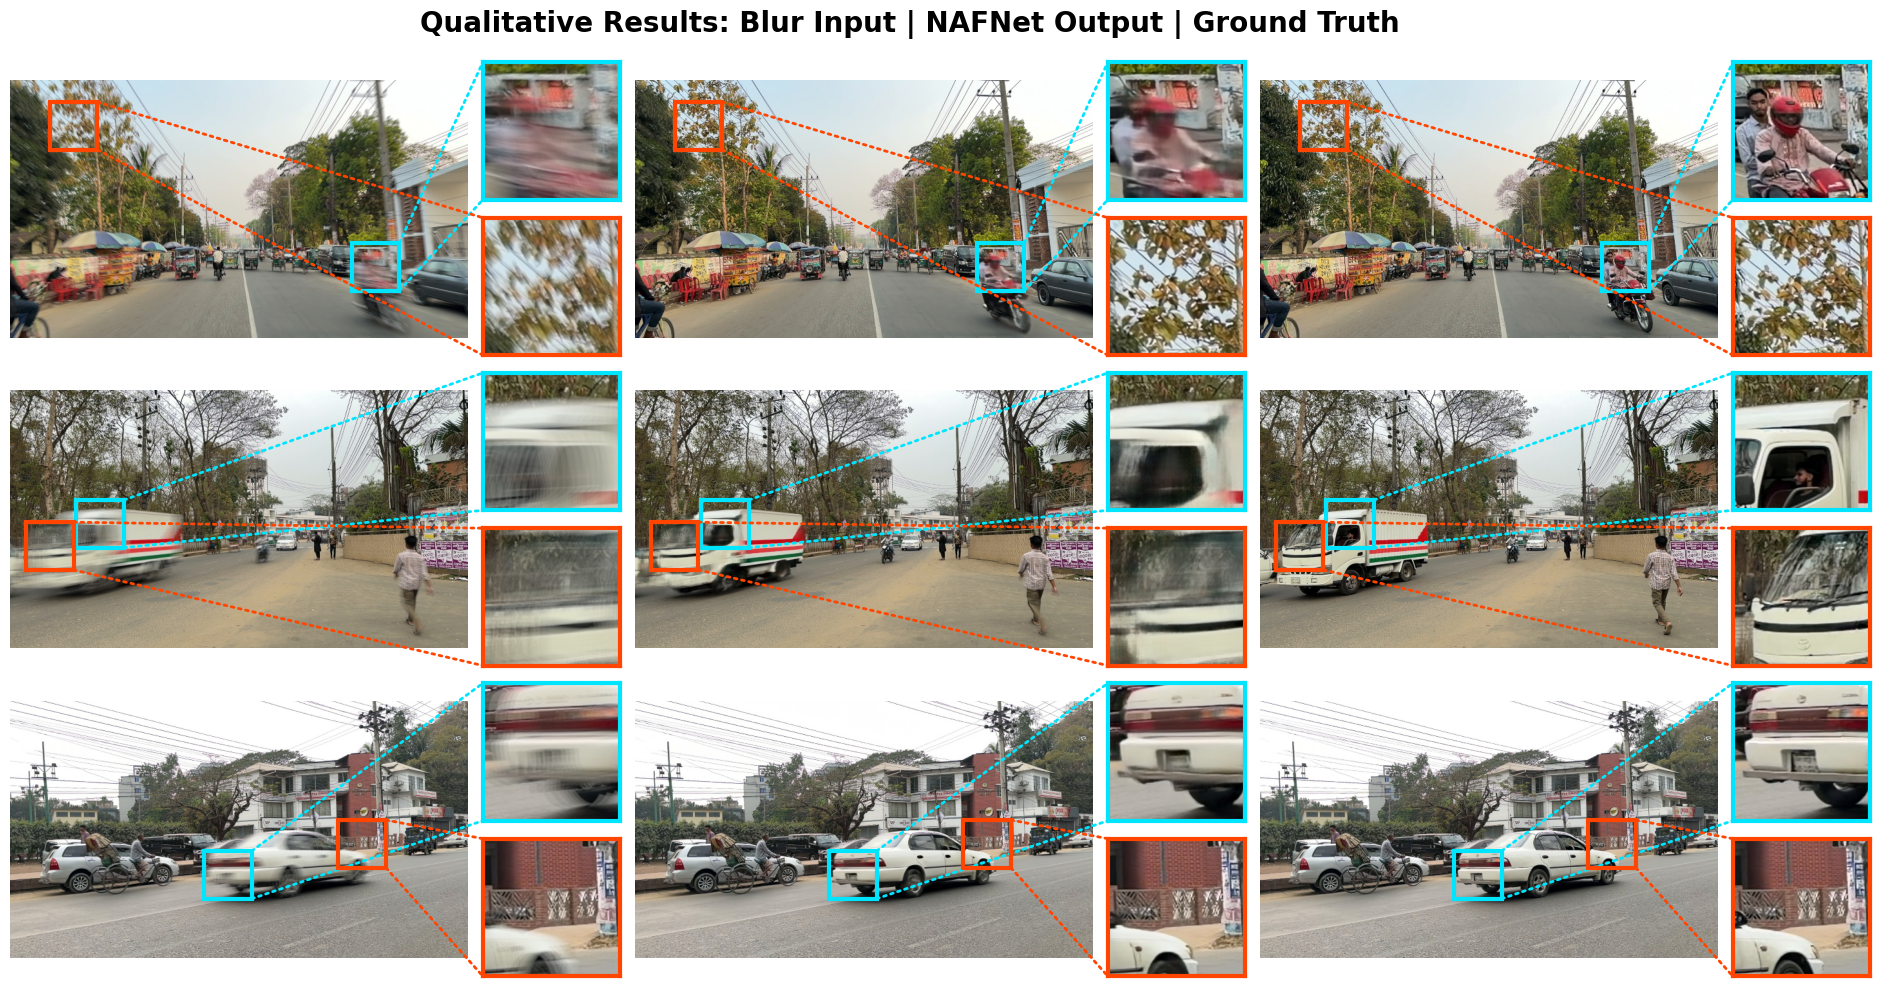

In [3]:
# ============================================================================
# CELL 3: NAFNET – QUALITATIVE GRID FOR 3 SPECIFIC IMAGES
# ============================================================================

image_specs = [
    ("IMG_2983", "00173"),
    ("IMG_2190", "00447"),
    ("IMG_2194", "00171")
]

dataset_root = Path('/kaggle/input/datasets/shafi09/iphoneblur/iPhoneBlur')
metadata_path = Path('/kaggle/input/datasets/shafi09/iphoneblur/iPhoneBlur/metadata/complete_metadata.csv')

if metadata_path.exists():
    full_metadata = pd.read_csv(metadata_path)
    full_metadata['img_id'] = full_metadata['img_id'].astype(str)
else:
    full_metadata = None

splits = ['test', 'train']
sample_list = []

for dir_base, frame in image_specs:
    img_id = f"{dir_base}_{frame}"
    found = False
    for split in splits:
        for folder in [dir_base, f"{dir_base}.MOV"]:
            blur_path = dataset_root / split / folder / 'blur' / f"{frame}.jpg"
            sharp_path = dataset_root / split / folder / 'sharp' / f"{frame}.jpg"
            if blur_path.exists() and sharp_path.exists():
                diff = "Unknown"
                if full_metadata is not None and img_id in full_metadata['img_id'].values:
                    diff = full_metadata[full_metadata['img_id'] == img_id]['difficulty'].values[0]
                sample_list.append((blur_path, sharp_path, diff))
                print(f"✅ Found: {img_id} in {split}/{folder} → {diff}")
                found = True
                break
        if found:
            break
    if not found:
        print(f"❌ Could not find {img_id} in test or train.")

if len(sample_list) == 3:
    generate_qualitative_grid(model, sample_list, device, model_name="NAFNet", patch_size=200, pad_to=16)
else:
    print(f"❌ Only {len(sample_list)} of 3 images found. Cannot generate grid.")